# Exercise 3
**Veikka Immonen**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, Product
from itertools import product
from scipy.linalg import solve_triangular
import scipy.sparse as sp
from tqdm import tqdm

## Continuation of GP regression from Ex. 1

### Generate the data from the underlying true process

Data is from a model

$$
y = Hx + \epsilon
$$

* $x \sim \mathcal{GP}(0, c_\text{Matèrn}(x, x'))$
* $c_\text{Matèrn}(x, x') = \sigma^2 \frac{2^{1 - \nu}}{\Gamma(\nu)}\left(\sqrt{2\nu}\frac{||x - x'||}{\ell}\right)^\nu K_\nu\left(\sqrt{2\nu}\frac{||x - x'||}{\ell}\right)$
* $H$: select operator
* $\epsilon \sim \mathcal{N}(0, \sigma_\epsilon^2)$ 
* $n_\text{data} = 51$
* $n_\text{state} = 201$


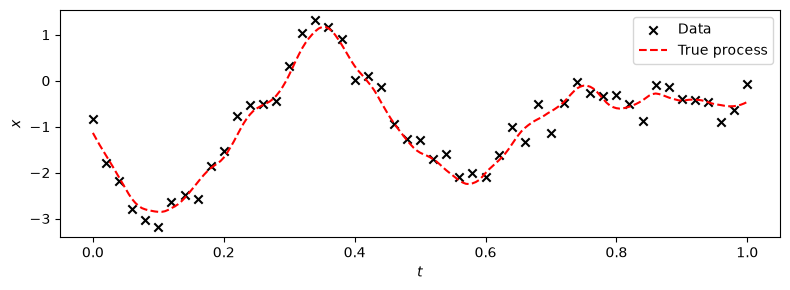

In [2]:
# true hyperparameters
nu_true = 2.5
ell_true = 0.1
scale_true = 1.0
var_true = 0.05

# sizes and the operator
n_data = 51
n_true = 201
step = (n_true - 1) // (n_data - 1)
operator = lambda x: x[::step]

# grid composition
t_data = np.arange(n_data).reshape((-1, 1)) / (n_data - 1)
t_true = np.arange(n_true).reshape((-1, 1)) / (n_true - 1)

# initialize the process
kernel_true = Product(
    ConstantKernel(constant_value=scale_true**2, constant_value_bounds="fixed"),
    Matern(length_scale=ell_true, length_scale_bounds="fixed", nu=nu_true)
)
gp_true = GaussianProcessRegressor(kernel=kernel_true)

# realization and "observations"
np.random.seed(24)
y_true = gp_true.sample_y(t_true)
y_data = operator(y_true) + var_true**(0.5) * np.random.randn(*t_data.shape)

# plot
_, ax = plt.subplots(figsize=(8, 3))
ax.set_xlabel("$t$")
ax.set_ylabel("$x$")

ax.scatter(t_data, y_data, c="k", marker="x", label="Data")
ax.plot(t_true, y_true, 'r--', label="True process")
ax.legend()

plt.tight_layout()
plt.savefig("data_and_true.pdf")
plt.show()

### Hierarchical model

For starters. Let's consider the full hierarchical model, when both the state and all hyperparameters are estimated. Let $\theta:=(\nu, \ell, \sigma, \sigma_\epsilon^2)$. The posterior of the hierarchical model is

$$
p(x, \theta | y) \propto \underbrace{p(y | x, \theta)}_\text{likelihood} \underbrace{p(x | \theta)}_\text{prior} \underbrace{p(\theta)}_\text{hyperprior}
$$

We can estimate $x$ and $\theta$ using a Metropolis-within-Gibbs (MWG) schema:

1. Fix $\theta$ and propose new sample $x'$ using pCN:
$$
    \alpha_\text{pCN} = \min\left\{1, \frac{p(y|x',\theta)}{p(y|x,\theta)} \right\}
$$
2. Fix $x$ and propose new sample $\theta'$ using MH:
$$
    \alpha_\text{MH} = \min\left\{1, \frac{p(y|x,\theta')p(x | \theta')p(\theta')}{p(y|x,\theta)p(x | \theta)p(\theta)} \right\}, 
$$

assuming that the sampling is a zero-mean Gaussian random walk in both cases.



In [3]:
def sample_gp(t, y, model_state, model_param,
              init_state, init_param, beta_state, beta_param,
              ll_pcn, lp_mh, chain_length):

    """
    t: state grid
    y: data
    model_state: mapping from sampled state to data
    model_param: mapping from sampled param to true form
    init_state: state initialization
    init_param: parameter initialization: (nu, ell, scale, sigma)
    beta_state: random walk step size in state sampling
    beta_param: random walk step size in param sampling
    ll_pcn: log-likelihood function for the pcn proposal
    lp_mh: log-posterior function for the mh proposal
    chain_length: length of the chain
    """

    chain_state = []
    chain_param = []

    # old samples
    state_old = init_state.copy()
    param_old = init_param.copy()
    L_old = init_zero_mean_gp(t, model_param(param_old))
    ll_state_old = ll_pcn(y, state_old, param_old, model_state, model_param)
    lp_param_old = lp_mh(y, state_old, param_old, L_old, model_state, model_param)

    # initialize new samples
    state_new = None
    param_new = None
    L_new = None
    ll_state_new = None
    lp_param_new = None

    # Misc
    alpha_state = (1 - beta_state**2)**.5
    fixed_kernel = np.all(beta_param[:3] == 0)

    for _ in tqdm(range(chain_length)):

        # sample state
        w = np.random.randn(*state_old.shape)
        state_new = alpha_state * state_old + beta_state * L_old @ w
        ll_state_new = ll_pcn(y, state_new, param_old, model_state, model_param)
        if np.log(np.random.rand()) <= min(ll_state_new - ll_state_old, 0):
            state_old = state_new
            ll_state_old = ll_state_new
            lp_param_old = lp_mh(y, state_old, param_old, L_old, model_state, model_param)

        # sample param
        w = np.random.randn(*param_old.shape)
        param_new = param_old + beta_param * w
        if not fixed_kernel:
            L_new = init_zero_mean_gp(t, model_param(param_new))
        lp_param_new = lp_mh(y, state_old, param_new, L_new, model_state, model_param)
        if np.log(np.random.rand()) <= min(lp_param_new - lp_param_old, 0):
            param_old = param_new
            if not fixed_kernel:
                L_old = L_new
            lp_param_old = lp_param_new

        # add to chain
        chain_state.append(state_old.ravel())
        chain_param.append(param_old)

    return tuple(map(np.asarray, (chain_state, chain_param)))


def init_zero_mean_gp(t, param):
    kernel = Product(
        ConstantKernel(constant_value=param[2]**2),
        Matern(length_scale=param[1], nu=param[0])
    )
    L = np.linalg.cholesky(kernel(t))
    return L


def fit_linear(X, y):
    X = np.pad(X, ((0, 0), (0, 1)), constant_values=1)
    b = np.linalg.solve(X.T @ X, X.T @ y)
    return b


def plot_results(t_true, y_true, t_data, y_data,
                 chain_state, chain_param, model_param,
                 tail_size, bins=100):

    # plot state
    mu_state = chain_state[-tail_size:].mean(0)
    std_state = chain_state[-tail_size:].std(0)
    RMSE = np.sqrt(np.mean((mu_state - y_true.ravel())**2))

    fig_state, ax_state = plt.subplots(figsize=(8, 3))
    ax_state.set_title(f"{RMSE = :.3f}")
    ax_state.set_xlabel("$t$")
    ax_state.set_ylabel("$x$")
    ax_state.scatter(t_data, y_data, c="k", marker="x", label="Data")
    ax_state.plot(t_true, y_true, 'r--', label="True process")
    ax_state.plot(t_true, mu_state, 'b--', label="Estimated process")
    ax_state.fill_between(t_true.ravel(), mu_state - 1.96*std_state,
                          mu_state + 1.96*std_state, alpha=0.5,
                          color='gray', edgecolor=None,
                          label="Credible interval (95%)")
    ax_state.legend()

    theta = np.apply_along_axis(model_param, 1, chain_param)

    # plot param chain
    fig_pchain, ax_pchain = plt.subplots(figsize=(8, 3))
    ax_pchain.set_xlabel("# sample")
    ax_pchain.set_ylabel("$\\theta$ value")
    names = ["$\\nu$", "$\\ell$", "$\\sigma$", "$\\sigma_\\epsilon^2$"]
    ax_pchain.plot(theta)
    ax_pchain.legend(names)

    # plot param hists
    title=""
    fig_phist, ax_phist = plt.subplots(figsize=(8, 3))
    ax_phist.set_xlabel("$\\theta$")
    ax_phist.set_ylabel("probability density")
    for name, chain in zip(names, theta.T):
        tail = chain[-tail_size:]
        ax_phist.hist(tail, bins=bins, density=True,
                      stacked=True, label=name)
        title += f"$\\mathbb{{E}}(${name}$) = {tail.mean():.3f}$, "
    ax_phist.set_title(title[:-2])
    ax_phist.set_ylim(0, bins+bins//10)
    ax_phist.legend()

    return (fig_state, ax_state), (fig_pchain, ax_pchain), (fig_phist, ax_phist)

### Sample only $x$ and $\sigma_\epsilon$

Now the model is considerably simpler, since Matèrn covariance stays fixed. We end up with

$$
p(x, \sigma_\epsilon | y) \propto p(y | x, \sigma_\epsilon) p(x) p(\sigma_\epsilon),
$$

and the prior term cancels in $\alpha_\text{MH}$ computation. Note, that

$$
p(y|x',\sigma_\epsilon) \propto \exp\left(-\frac{1}{2\sigma_\epsilon^2} ||y-Hx||^2 \right)
$$

#### Sampling $\sigma_\epsilon$ from log-Gaussian

Let $z := \log(\sigma_\epsilon^2) \sim \mathcal{N}(\mu_z, \sigma_z^2)$. We can sample $z$ directly and derive posterior as
$$
p(x, z | y) \propto p(y | x, z) p(x) p(z),
$$
where
$$
p(z) \propto \exp\left(-\frac{(\mu_z - z)^2}{2\sigma_z^2}\right).
$$

100%|██████████| 100000/100000 [00:01<00:00, 58010.39it/s]


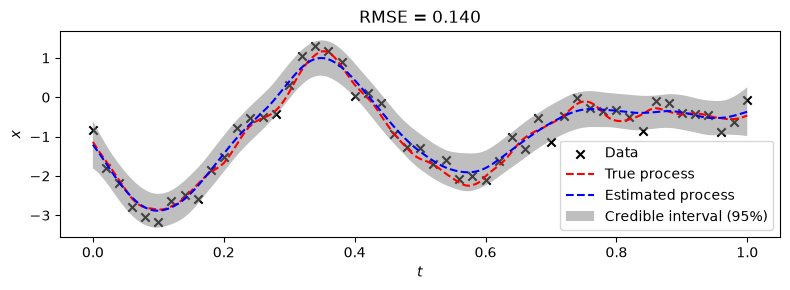

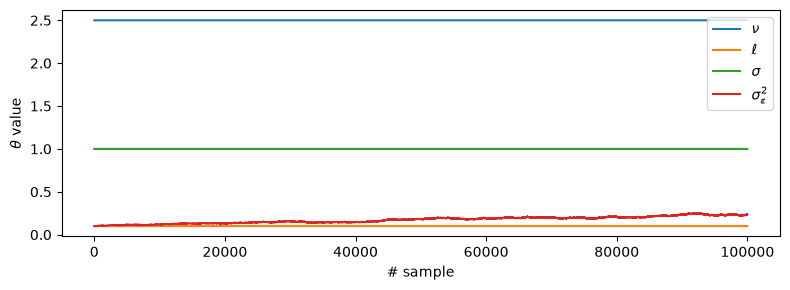

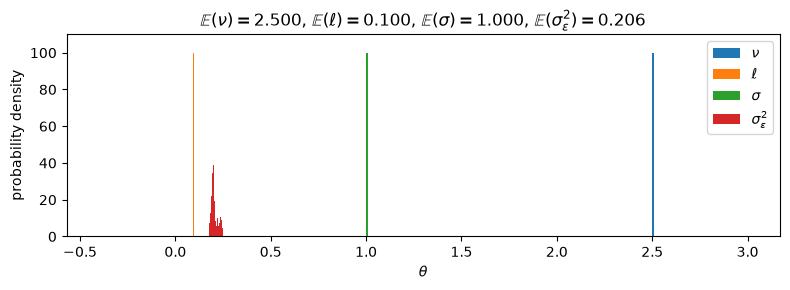

In [4]:
# models to transform state and data
model_state = operator
model_param = lambda x: np.exp(x)

# initial values, linear fit as a initial state,
# kernel parameters stay fixed
coeff = fit_linear(t_data, y_data).ravel()
init_state = t_true * coeff[0] + coeff[1]
init_param = np.log([2.5, 0.1, 1.0, 0.1])

# betas
beta_state = 1e-1
beta_param = np.array([0, 0, 0, 1e-3])


# log-likelihood
def log_likelihood(y, state, param, model_state, model_param):
    var_noise = model_param(param[-1])
    pred = model_state(state)
    return -0.5 * var_noise**(-1) * np.sum((y - pred)**2)


# log-posterior, without prior
def lp_mh_no_prior_gaussian(y, state, param, L, model_state, model_param):
    # z = log(noise deviation) ~ Gaussian (of own choice)
    mu_z = np.log(0.1)
    sigma_z = 1.0
    ll = log_likelihood(y, state, param, model_state, model_param)
    return ll - 0.5 * ((mu_z - param[-1]) / sigma_z) ** 2

# sample
chain_length = 100_000
chain_state, chain_param = sample_gp(
    t_true, y_data,
    model_state, model_param,
    init_state, init_param,
    beta_state, beta_param,
    log_likelihood, lp_mh_no_prior_gaussian,
    chain_length
)

# plot results
(fig_state, ax_state), (fig_pchain, ax_pchain), (fig_phist, ax_phist) = \
    plot_results(t_true, y_true, t_data, y_data,
                 chain_state, chain_param,
                 model_param, chain_length//2)

fig_state.tight_layout()
fig_pchain.tight_layout()
fig_phist.tight_layout()

fig_state.savefig("1_1_1_state.pdf")
fig_pchain.savefig("1_1_1_pchain.pdf")
fig_phist.savefig("1_1_1_phist.pdf")

#### Sampling $\sigma_\epsilon$ from uniform distribution

Define $z$ as $|z| = \sigma_\epsilon^2$ and $z \sim \mathcal{U}\left[-\infty, \infty\right]$. Again we sample $z$ directly. Since z is uniform (and covariance hyperparameters are fixed), the posterior is equivalent to the likelihood.

100%|██████████| 100000/100000 [00:01<00:00, 53133.72it/s]


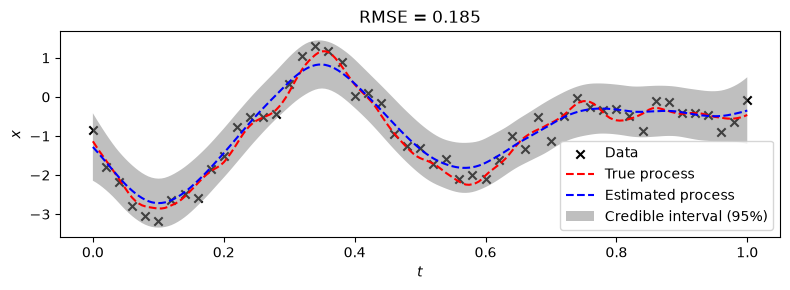

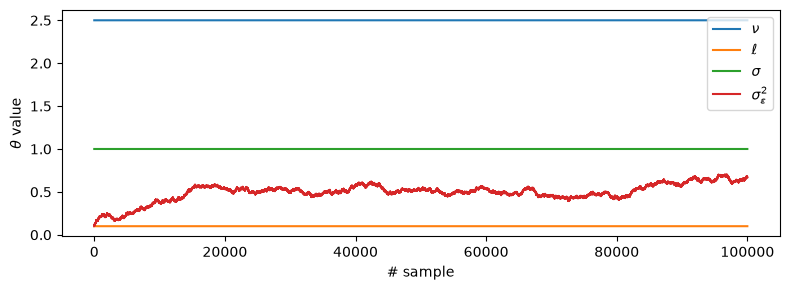

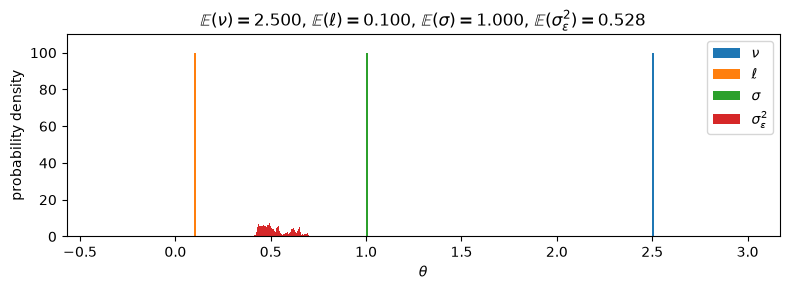

In [5]:
# models to transform state and data
model_state = operator
model_param = lambda x: np.abs(x)

# initial values, linear fit as a initial state,
# kernel parameters stay fixed
coeff = fit_linear(t_data, y_data).ravel()
init_state = t_true * coeff[0] + coeff[1]
init_param = np.array([2.5, 0.1, 1.0, 0.1])

# betas
beta_state = 1e-1
beta_param = np.array([0, 0, 0, 1e-3])


# log-likelihood
def log_likelihood(y, state, param, model_state, model_param):
    _, _, _, var_noise = model_param(param)
    pred = model_state(state)
    return -0.5 * var_noise**(-1) * np.sum((y - pred)**2)

# log-posterior
def lp_mh_no_prior_uniform(y, state, param, L, model_state, model_param):
    return log_likelihood(y, state, param, model_state, model_param)

# sample
chain_length = 100_000
chain_state, chain_param = sample_gp(
    t_true, y_data,
    model_state, model_param,
    init_state, init_param,
    beta_state, beta_param,
    log_likelihood, lp_mh_no_prior_uniform,
    chain_length
)

# plot results
(fig_state, ax_state), (fig_pchain, ax_pchain), (fig_phist, ax_phist) = \
    plot_results(t_true, y_true, t_data, y_data,
                 chain_state, chain_param,
                 model_param, chain_length//2)

fig_state.tight_layout()
fig_pchain.tight_layout()
fig_phist.tight_layout()

fig_state.savefig("1_1_2_state.pdf")
fig_pchain.savefig("1_1_2_pchain.pdf")
fig_phist.savefig("1_1_2_phist.pdf")

### Sample only $x$ and $\nu$, $\sigma_\epsilon$

Now the posterior is

$$
p(x, \nu, \sigma_\epsilon | y) \propto p(y | x, \nu, \sigma_\epsilon) p(x | \nu) p(\nu, \sigma_\epsilon),
$$

yet $\alpha_\text{pCN}$ remains the same, but

$$
    \alpha_\text{MH} = \min\left\{1, \frac{p(y | x, \nu', \sigma_\epsilon') p(x | \nu') p(\nu', \sigma_\epsilon')}{p(y | x, \nu, \sigma_\epsilon) p(x | \nu) p(\nu, \sigma_\epsilon)} \right\},
$$

where
$$
p(x | \nu) \propto \exp\left(-\frac{1}{2} (x^\intercal K_\nu^{-1} x + \log |K_{\nu}|)\right)
$$

#### Sampling $\sigma_\epsilon$ and $\nu$ from log-Gaussian

Let $z := \log((\nu, \sigma_\epsilon^2)) \sim \mathcal{N}(\mu_z, \mathrm{diag}\{\sigma_z^2\})$.

100%|██████████| 20000/20000 [02:22<00:00, 140.49it/s]


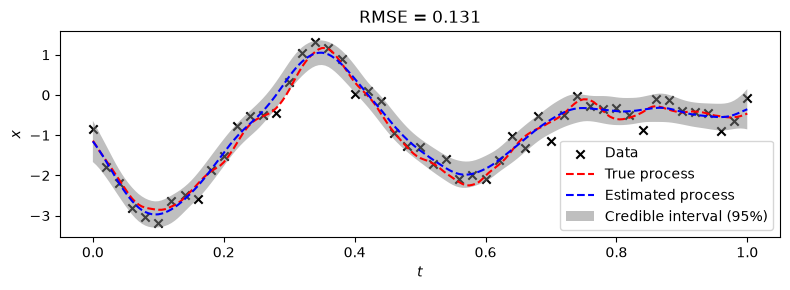

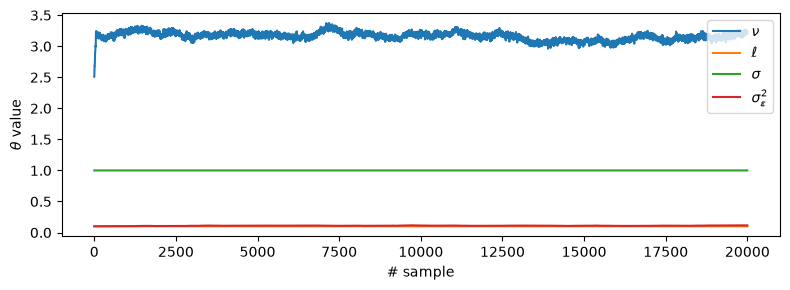

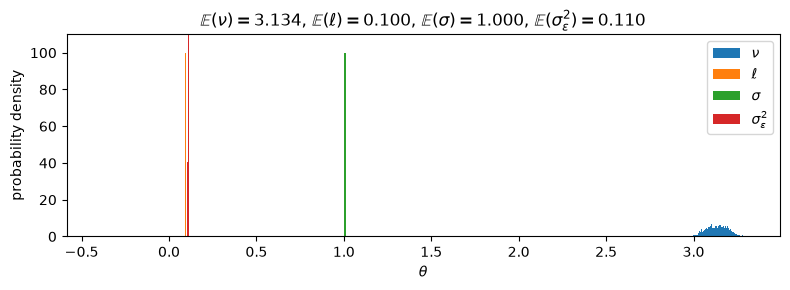

In [6]:
# models to transform state and data
model_state = operator
model_param = lambda x: np.exp(x)

# initial values, linear fit as a initial state,
# kernel parameters stay fixed
coeff = fit_linear(t_data, y_data).ravel()
init_state = t_true * coeff[0] + coeff[1]
init_param = np.log([2.5, 0.1, 1.0, 0.1])

# betas
beta_state = 1e-1
beta_param = np.array([1e-2, 0, 0, 1e-3])


# log-likelihood
def log_likelihood(y, state, param, model_state, model_param):
    var_noise = model_param(param[-1])
    pred = model_state(state)
    return -0.5 * var_noise**(-1) * np.sum((y - pred)**2)


# log-posterior
def lp_mh_no_prior_gaussian(y, state, param, L, model_state, model_param):
    # z = log(noise deviation) ~ Gaussian (of own choice)
    mu_z = np.log([1.5, 0.1])
    sigma_z = np.array([1., 1.])
    w = solve_triangular(L, state, lower=True)
    z = param[[0, 3]]
    ll = log_likelihood(y, state, param, model_state, model_param)
    lp = -0.5 * np.sum(w**2) - np.sum(np.log(np.diag(L)))
    lhp = -0.5 * np.sum(((z - mu_z) / sigma_z)**2)
    return ll + lp + lhp


# sample
chain_length = 20_000
chain_state, chain_param = sample_gp(
    t_true, y_data,
    model_state, model_param,
    init_state, init_param,
    beta_state, beta_param,
    log_likelihood, lp_mh_no_prior_gaussian,
    chain_length
)

# plot results
(fig_state, ax_state), (fig_pchain, ax_pchain), (fig_phist, ax_phist) = \
    plot_results(t_true, y_true, t_data, y_data,
                 chain_state, chain_param,
                 model_param, chain_length//2)

fig_state.tight_layout()
fig_pchain.tight_layout()
fig_phist.tight_layout()

fig_state.savefig("1_1_3_state.pdf")
fig_pchain.savefig("1_1_3_pchain.pdf")
fig_phist.savefig("1_1_3_phist.pdf")

#### Sampling $\nu$ and $\sigma_\epsilon$ from uniform distribution

Define $z$ as $|z| = (\nu, \sigma_\epsilon^2)$ and $z \sim \mathcal{U}\left[-\infty, \infty\right]$. Only the hyperprior term calcels out in the $\alpha_\text{MH}$ computation.

100%|██████████| 20000/20000 [02:22<00:00, 140.53it/s]


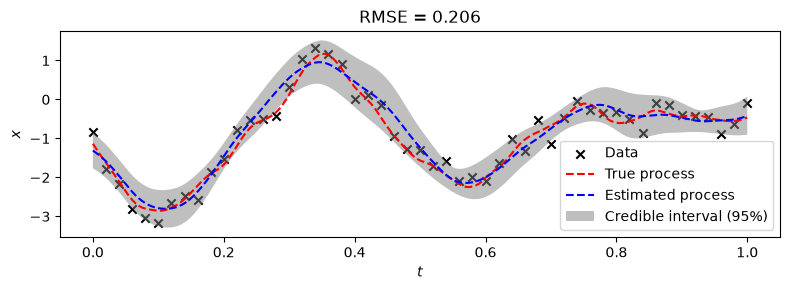

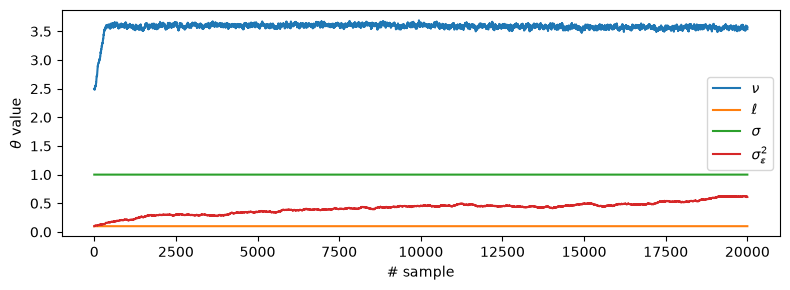

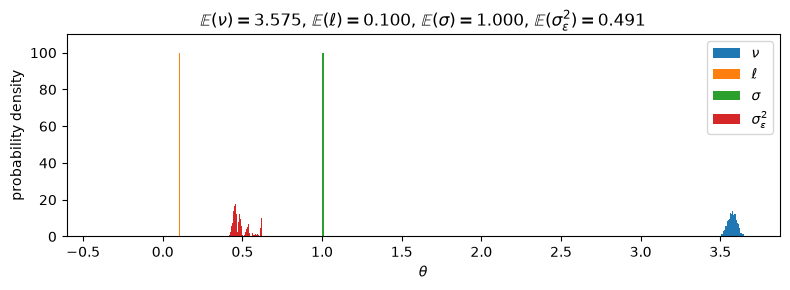

In [7]:

# models to transform state and data
model_state = operator
model_param = lambda x: np.abs(x)

# initial values, linear fit as a initial state,
# kernel parameters stay fixed
coeff = fit_linear(t_data, y_data).ravel()
init_state = t_true * coeff[0] + coeff[1]
init_param = np.array([2.5, 0.1, 1.0, 0.1])

# betas
beta_state = 1e-2
beta_param = np.array([1e-2, 0, 0, 1e-3])


# log-likelihood
def log_likelihood(y, state, param, model_state, model_param):
    var_noise = model_param(param[-1])
    pred = model_state(state)
    return -0.5 * var_noise**(-1) * np.sum((y - pred)**2)


# log-posterior, no hyperprior
def lp_mh_no_prior_gaussian(y, state, param, L, model_state, model_param):
    # z = log(noise deviation) ~ Gaussian (of own choice)
    w = solve_triangular(L, state, lower=True)
    ll = log_likelihood(y, state, param, model_state, model_param)
    lp = -0.5 * np.sum(w**2) - np.sum(np.log(np.diag(L)))
    return ll + lp


# sample
chain_length = 20_000
chain_state, chain_param = sample_gp(
    t_true, y_data,
    model_state, model_param,
    init_state, init_param,
    beta_state, beta_param,
    log_likelihood, lp_mh_no_prior_gaussian,
    chain_length
)

# plot results
(fig_state, ax_state), (fig_pchain, ax_pchain), (fig_phist, ax_phist) = \
    plot_results(t_true, y_true, t_data, y_data,
                 chain_state, chain_param,
                 model_param, chain_length//2)

fig_state.tight_layout()
fig_pchain.tight_layout()
fig_phist.tight_layout()

fig_state.savefig("1_1_4_state.pdf")
fig_pchain.savefig("1_1_4_pchain.pdf")
fig_phist.savefig("1_1_4_phist.pdf")

## From GPr to inverse problems

### Discrete matrix approximation

To discretize the model
$$
y(t) = \int K(t-t')x(t')dt' + \epsilon(t)
$$
to
$$
y = Kx + \epsilon
$$
Where $K$ is a convolution kernel with a local support. Now K is a boxcar kernel with parameter $a$.
$$
K_a(t - t') = \begin{cases}\frac{1}{2a}, & |t-t'| \le a \\ 0, & \text{otherwise}\end{cases}
$$
Normalization $\frac{1}{2a}$ makes the convolution a local average:
$$
y(t) = \frac{1}{2a}\int_{t-a}^{t+a}x(t')\text{d}t' + \epsilon(t).
$$
Define the underlying signal as
$$
x(t) = \begin{cases}
\exp\left(4 - \frac{25}{10t(5 - 10t)}\right), & t\in(0,0.5) \\
1, & t\in[0.7, 0.8] \\
-1, & t\in(0.8, 0.9] \\
0, & \text{otherwise}
\end{cases},
$$
For the discrete problem, take $t_i = i \Delta t,\ i=0,...,n$ (state discretization), and approximate the integral by quadrature
$$
y_i \approx \sum_{j=0}^{N-1}K_a(t_i - t_j)x_j \Delta t
$$
Therefore in our forward matrix is:
$$
K_{i,j} = K_a(t_i - t_j) \Delta t.
$$
* $a = 0.1$
* $\epsilon \sim \mathcal{N}(0, \sigma_\epsilon^2)$ 
* $n_\text{data} = 51$
* $n_\text{state} = 201$

/var/folders/r7/lrp1vtg90zx0m34pgg8fr_bs0yg2r7/T/ipykernel_82948/534974879.py:2: RuntimeWarning: divide by zero encountered in divide
  term_1 = (x > 0) * (x < .5) * np.exp(4 - 25 / (10*x * (5 - 10*x)))


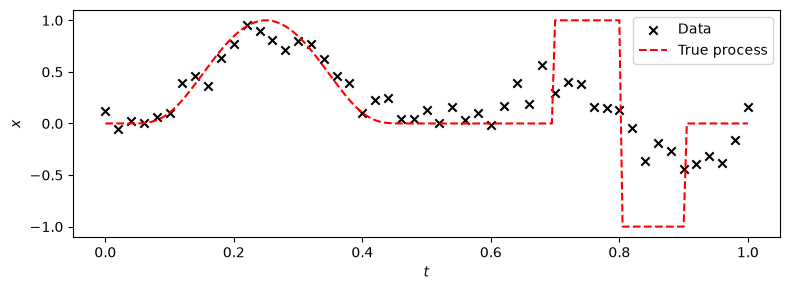

In [8]:
def signal_true(x):
    term_1 = (x > 0) * (x < .5) * np.exp(4 - 25 / (10*x * (5 - 10*x)))
    term_2 = (x >= .7) * (x <= .8) * np.ones_like(x)
    term_3 = (x > .8) * (x <= .9) * (-np.ones_like(x))
    return term_1 + term_2 + term_3

def periodic_boxcar_operator(t1, t2, a):
    n, m = map(len, (t1, t2))
    dt = (t1[1] - t1[0]).item()
    c = dt / (2 * a)
    K = np.zeros((m, n))
    for i, j in product(range(m), range(n)):
        d = abs(t2[i] - t1[j])
        d_periodic = min(d, 1.0 - d)
        if d_periodic <= a: K[i, j] = c
    # normalize each row to preserve K@1 = (1,1,...,1)
    return K / np.sum(K, axis=1, keepdims=True)

n_true = 201
n_data = 51

t_true = np.arange(n_true)[:, None] / (n_true - 1)
t_data = np.arange(n_data)[:, None] / (n_data - 1)

a = 0.1
var_true = 0.01
K = periodic_boxcar_operator(t_true, t_data, a)
operator = lambda x: K @ x

np.random.seed(24)
x_true = signal_true(t_true)
y_data  = operator(x_true) + var_true**.5 * np.random.randn(*t_data.shape)

# plot
_, ax = plt.subplots(figsize=(8, 3))
ax.set_xlabel("$t$")
ax.set_ylabel("$x$")

ax.scatter(t_data, y_data, c="k", marker="x", label="Data")
ax.plot(t_true, x_true, 'r--', label="True process")
ax.legend()

plt.tight_layout()
plt.savefig("data_and_true_2.pdf")
plt.show()


### Sample only $x$ and $\sigma_\epsilon$

The hierarchical model including the simplifications along the way remains pretty much the same. Only difference is that we are using a different linear operator.

Also, the sampled Matèrn process is using now $\sigma=2.0$ to match the process scale better to underlying signal.

#### Sampling $\sigma_\epsilon$ from log-Gaussian

100%|██████████| 100000/100000 [00:01<00:00, 54061.88it/s]


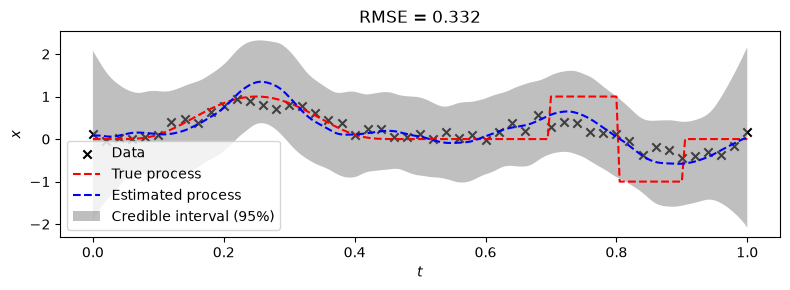

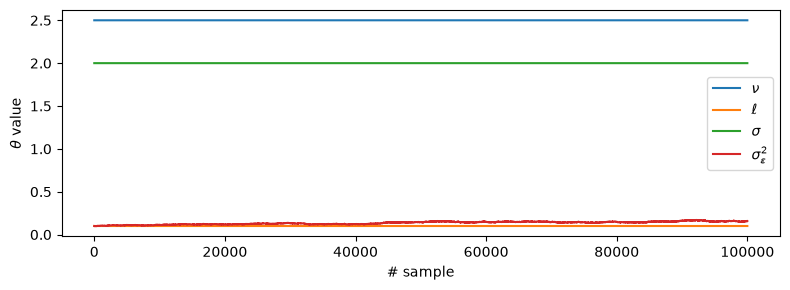

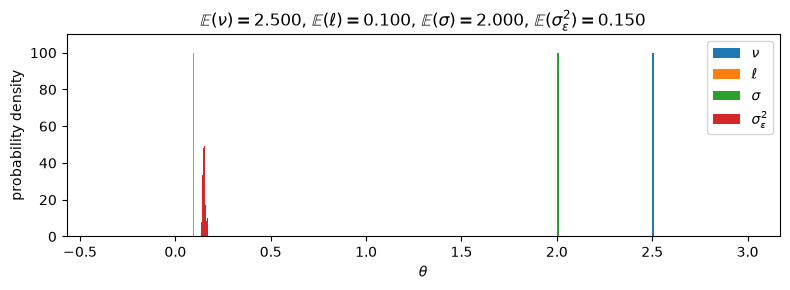

In [9]:
# models to transform state and data
model_state = operator
model_param = lambda x: np.exp(x)

# initial values, linear fit as a initial state,
# kernel parameters stay fixed
coeff = fit_linear(t_data, y_data).ravel()
init_state = t_true * coeff[0] + coeff[1]
init_param = np.log([2.5, 0.1, 2.0, 0.1])

# betas
beta_state = 1e-1
beta_param = np.array([0, 0, 0, 1e-3])


# log-likelihood
def log_likelihood(y, state, param, model_state, model_param):
    var_noise = model_param(param[-1])
    pred = model_state(state)
    return -0.5 * var_noise**(-1) * np.sum((y - pred)**2)


# log-posterior, without prior
def lp_mh_no_prior_gaussian(y, state, param, L, model_state, model_param):
    # z = log(noise deviation) ~ Gaussian (of own choice)
    mu_z = np.log(0.1)
    sigma_z = 1.0
    ll = log_likelihood(y, state, param, model_state, model_param)
    return ll - 0.5 * ((mu_z - param[-1]) / sigma_z) ** 2

# sample
chain_length = 100_000
chain_state, chain_param = sample_gp(
    t_true, y_data,
    model_state, model_param,
    init_state, init_param,
    beta_state, beta_param,
    log_likelihood, lp_mh_no_prior_gaussian,
    chain_length
)

# plot results
(fig_state, ax_state), (fig_pchain, ax_pchain), (fig_phist, ax_phist) = \
    plot_results(t_true, x_true, t_data, y_data,
                 chain_state, chain_param,
                 model_param, chain_length//2)

fig_state.tight_layout()
fig_pchain.tight_layout()
fig_phist.tight_layout()

fig_state.savefig("2_1_1_state.pdf")
fig_pchain.savefig("2_1_1_pchain.pdf")
fig_phist.savefig("2_1_1_phist.pdf")

#### Sampling $\sigma_\epsilon$ from uniform

100%|██████████| 100000/100000 [00:01<00:00, 50468.68it/s]


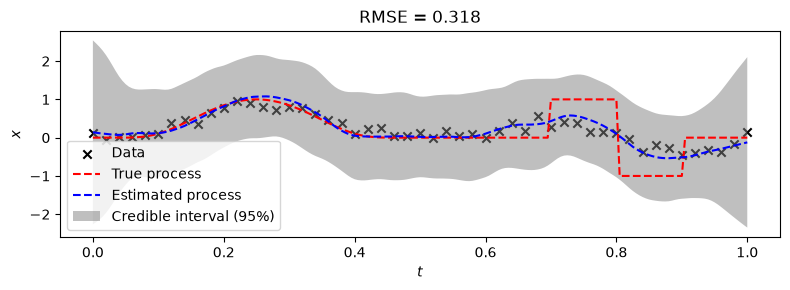

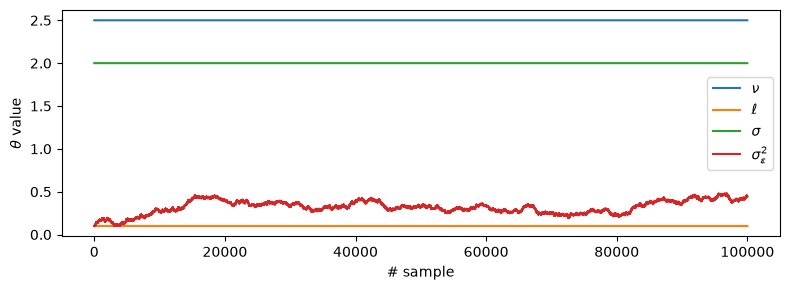

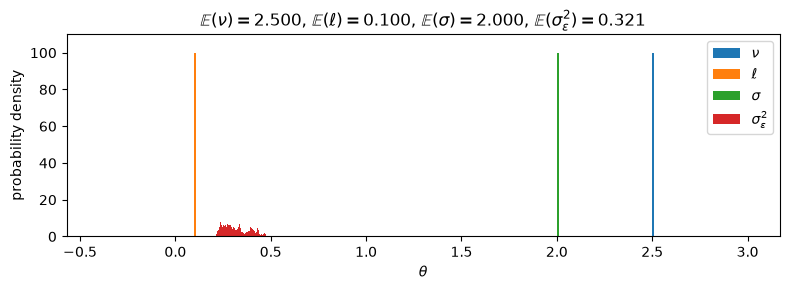

In [10]:
# models to transform state and data
model_state = operator
model_param = lambda x: np.abs(x)

# initial values, linear fit as a initial state,
# kernel parameters stay fixed
coeff = fit_linear(t_data, y_data).ravel()
init_state = t_true * coeff[0] + coeff[1]
init_param = np.array([2.5, 0.1, 2.0, 0.1])

# betas
beta_state = 1e-1
beta_param = np.array([0, 0, 0, 1e-3])


# log-likelihood
def log_likelihood(y, state, param, model_state, model_param):
    _, _, _, var_noise = model_param(param)
    pred = model_state(state)
    return -0.5 * var_noise**(-1) * np.sum((y - pred)**2)

# log-posterior
def lp_mh_no_prior_uniform(y, state, param, L, model_state, model_param):
    return log_likelihood(y, state, param, model_state, model_param)

# sample
chain_length = 100_000
chain_state, chain_param = sample_gp(
    t_true, y_data,
    model_state, model_param,
    init_state, init_param,
    beta_state, beta_param,
    log_likelihood, lp_mh_no_prior_uniform,
    chain_length
)

# plot results
(fig_state, ax_state), (fig_pchain, ax_pchain), (fig_phist, ax_phist) = \
    plot_results(t_true, x_true, t_data, y_data,
                 chain_state, chain_param,
                 model_param, chain_length//2)

fig_state.tight_layout()
fig_pchain.tight_layout()
fig_phist.tight_layout()

fig_state.savefig("2_1_2_state.pdf")
fig_pchain.savefig("2_1_2_pchain.pdf")
fig_phist.savefig("2_1_2_phist.pdf")

### Sample only $x$ and $\nu$, $\sigma_\epsilon$

#### Sampling $\sigma_\epsilon$ and $\nu$ from log-Gaussian

100%|██████████| 20000/20000 [02:25<00:00, 137.89it/s]


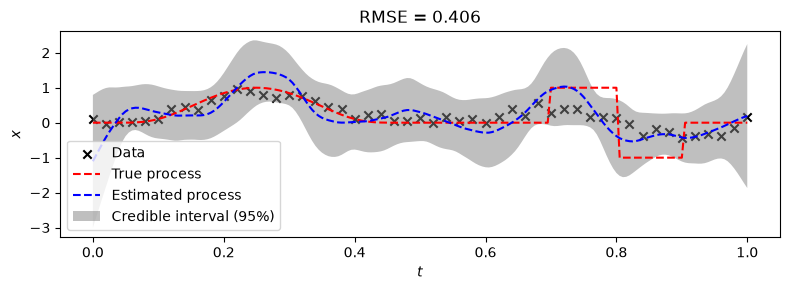

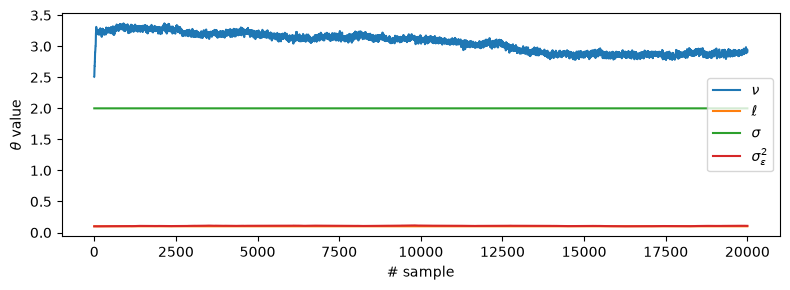

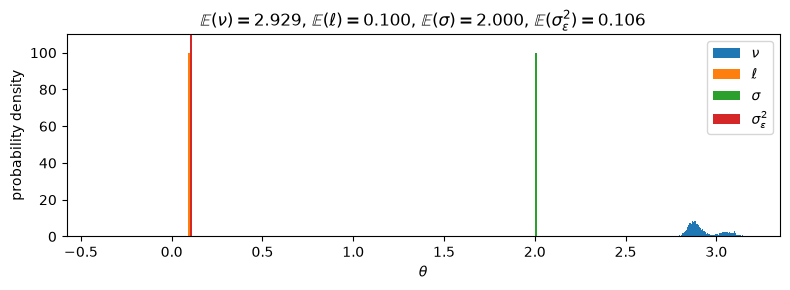

In [11]:
# models to transform state and data
model_state = operator
model_param = lambda x: np.exp(x)

# initial values, linear fit as a initial state,
# kernel parameters stay fixed
coeff = fit_linear(t_data, y_data).ravel()
init_state = t_true * coeff[0] + coeff[1]
init_param = np.log([2.5, 0.1, 2.0, 0.1])

# betas
beta_state = 1e-1
beta_param = np.array([1e-2, 0, 0, 1e-3])


# log-likelihood
def log_likelihood(y, state, param, model_state, model_param):
    var_noise = model_param(param[-1])
    pred = model_state(state)
    return -0.5 * var_noise**(-1) * np.sum((y - pred)**2)


# log-posterior
def lp_mh_no_prior_gaussian(y, state, param, L, model_state, model_param):
    # z = log(noise deviation) ~ Gaussian (of own choice)
    mu_z = np.log([1.5, 0.1])
    sigma_z = np.array([1., 1.])
    w = solve_triangular(L, state, lower=True)
    z = param[[0, 3]]
    ll = log_likelihood(y, state, param, model_state, model_param)
    lp = -0.5 * np.sum(w**2) - np.sum(np.log(np.diag(L)))
    lhp = -0.5 * np.sum(((z - mu_z) / sigma_z)**2)
    return ll + lp + lhp


# sample
chain_length = 20_000
chain_state, chain_param = sample_gp(
    t_true, y_data,
    model_state, model_param,
    init_state, init_param,
    beta_state, beta_param,
    log_likelihood, lp_mh_no_prior_gaussian,
    chain_length
)

# plot results
(fig_state, ax_state), (fig_pchain, ax_pchain), (fig_phist, ax_phist) = \
    plot_results(t_true, x_true, t_data, y_data,
                 chain_state, chain_param,
                 model_param, chain_length//2)

fig_state.tight_layout()
fig_pchain.tight_layout()
fig_phist.tight_layout()

fig_state.savefig("2_1_3_state.pdf")
fig_pchain.savefig("2_1_3_pchain.pdf")
fig_phist.savefig("2_1_3_phist.pdf")

#### Sampling $\sigma_\epsilon$ and $\nu$ from uniform

100%|██████████| 20000/20000 [02:20<00:00, 142.72it/s]


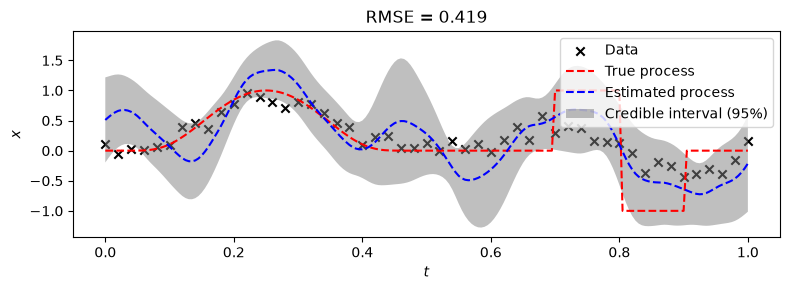

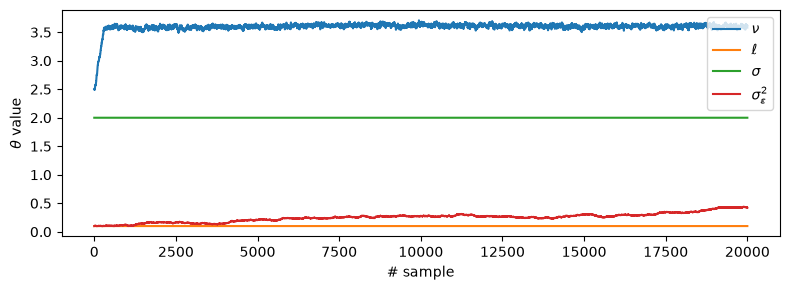

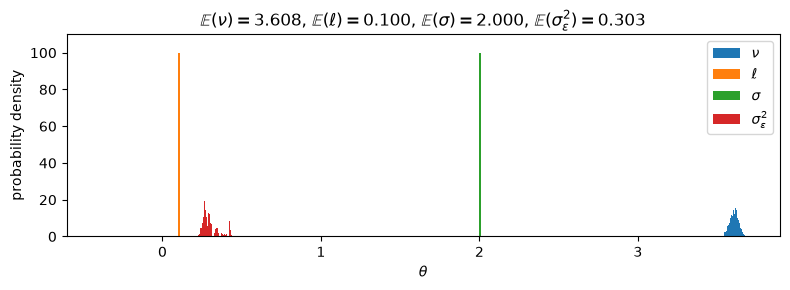

In [12]:
# models to transform state and data
model_state = operator
model_param = lambda x: np.abs(x)

# initial values, linear fit as a initial state,
# kernel parameters stay fixed
coeff = fit_linear(t_data, y_data).ravel()
init_state = t_true * coeff[0] + coeff[1]
init_param = np.array([2.5, 0.1, 2.0, 0.1])

# betas
beta_state = 1e-2
beta_param = np.array([1e-2, 0, 0, 1e-3])


# log-likelihood
def log_likelihood(y, state, param, model_state, model_param):
    var_noise = model_param(param[-1])
    pred = model_state(state)
    return -0.5 * var_noise**(-1) * np.sum((y - pred)**2)


# log-posterior, no hyperprior
def lp_mh_no_prior_gaussian(y, state, param, L, model_state, model_param):
    # z = log(noise deviation) ~ Gaussian (of own choice)
    w = solve_triangular(L, state, lower=True)
    ll = log_likelihood(y, state, param, model_state, model_param)
    lp = -0.5 * np.sum(w**2) - np.sum(np.log(np.diag(L)))
    return ll + lp


# sample
chain_length = 20_000
chain_state, chain_param = sample_gp(
    t_true, y_data,
    model_state, model_param,
    init_state, init_param,
    beta_state, beta_param,
    log_likelihood, lp_mh_no_prior_gaussian,
    chain_length
)

# plot results
(fig_state, ax_state), (fig_pchain, ax_pchain), (fig_phist, ax_phist) = \
    plot_results(t_true, x_true, t_data, y_data,
                 chain_state, chain_param,
                 model_param, chain_length//2)

fig_state.tight_layout()
fig_pchain.tight_layout()
fig_phist.tight_layout()

fig_state.savefig("2_1_4_state.pdf")
fig_pchain.savefig("2_1_4_pchain.pdf")
fig_phist.savefig("2_1_4_phist.pdf")